In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**ResNet50**

https://keras.io/api/applications/resnet/

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

model = ResNet50(weights='imagenet')

img_path = '/content/drive/MyDrive/FMAT/MIA/Introduccion_IA/Notebooks/elephant.jpeg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
print('Predicted:', decode_predictions(preds, top=5)[0])

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Predicted: [('n01871265', 'tusker', np.float32(0.56793165)), ('n02504458', 'African_elephant', np.float32(0.3936353)), ('n02504013', 'Indian_elephant', np.float32(0.03647741)), ('n02093647', 'Bedlington_terrier', np.float32(0.0006024619)), ('n02437312', 'Arabian_camel', np.float32(0.00014879518))]


In [4]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

#Re-entrenando la RestNet-50

In [ ]:
model = ResNet50(include_top=False, weights='imagenet', input_shape=(100,100,3))

94765736/94765736 [==============================] - 1s 0us/step


In [ ]:
model.summary()

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 100, 100, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 106, 106, 3)          0         ['input_2[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 50, 50, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 50, 50, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [ ]:
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(archive).with_suffix('')

228813984/228813984 [==============================] - 3s 0us/step


flowers_photos/

  daisy/

  dandelion/

  roses/

  sunflowers/
  
  tulips/

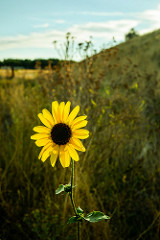

In [ ]:
roses = list(data_dir.glob('roses/*'))
sunflowers = list(data_dir.glob('sunflowers/*'))
PIL.Image.open(str(sunflowers[200]))

In [ ]:
print(len(roses))
print(len(sunflowers))

641
699


In [ ]:
X_train = np.zeros((1,100,100,3))
newsize = (100, 100)
for i in range(641):#(len(roses)):
  r = PIL.Image.open(str(roses[i]))
  r = r.resize(newsize)
  r = np.array(r)
  r = r.reshape((1,100,100,3))
  X_train = np.concatenate((X_train, r), axis=0)

X_train = np.delete(X_train, 0, 0)
print(X_train.shape)

for i in range(641):#(len(sunflowers)):
  r = PIL.Image.open(str(sunflowers[i]))
  r = r.resize(newsize)
  r = np.array(r)
  r = r.reshape((1,100,100,3))
  X_train = np.concatenate((X_train, r), axis=0)

print(X_train.shape)

(641, 100, 100, 3)
(1282, 100, 100, 3)


In [ ]:
y_train = np.zeros(641)
y_train = np.concatenate((y_train, np.ones(641)), axis=0)
print(y_train.shape)
y_train = y_train.reshape((1282,1))
print(y_train.shape)

(1282,)
(1282, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical

print(X_train.shape)
print(y_train.shape)
print(y_train[800])
y_train = to_categorical(y_train)
print(y_train[800])

(1282, 100, 100, 3)
(1282, 1)
[1.]
[0. 1.]


In [ ]:
# Freeze the layers which you don't want to train. Here I am freezing all layers.
for layer in model.layers[:]:
    layer.trainable = False

# Adding custom Layer
# We only add
x = model.output
x = keras.layers.Flatten()(x)
# Adding even more custom layers
# x = Dense(1024, activation="relu")(x)
# x = Dropout(0.5)(x)
# x = Dense(1024, activation="relu")(x)
predictions = keras.layers.Dense(2, activation="softmax")(x)
# creating the final model
model_final = tf.keras.Model(model.input, predictions)

In [ ]:
model_final.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 100, 100, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 106, 106, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 50, 50, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 50, 50, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [ ]:
# compile the model
model_final.compile(loss = "categorical_crossentropy", optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9), metrics=["accuracy"]);

In [ ]:
model_final.fit(X_train, y_train, epochs=20, validation_split = 0.2)

Epoch 1/20
33/33 [==============================] - 7s 95ms/step - loss: 0.4439 - accuracy: 0.8380 - val_loss: 0.3173 - val_accuracy: 0.9066
Epoch 2/20
33/33 [==============================] - 1s 39ms/step - loss: 0.1496 - accuracy: 0.9483 - val_loss: 0.3161 - val_accuracy: 0.9105
Epoch 3/20
33/33 [==============================] - 1s 41ms/step - loss: 0.0617 - accuracy: 0.9785 - val_loss: 0.5368 - val_accuracy: 0.8444
Epoch 4/20
33/33 [==============================] - 1s 39ms/step - loss: 0.0433 - accuracy: 0.9815 - val_loss: 0.2181 - val_accuracy: 0.9377
Epoch 5/20
33/33 [==============================] - 1s 37ms/step - loss: 0.0232 - accuracy: 0.9961 - val_loss: 0.2972 - val_accuracy: 0.9144
Epoch 6/20
33/33 [==============================] - 1s 40ms/step - loss: 0.0178 - accuracy: 0.9980 - val_loss: 0.2749 - val_accuracy: 0.9222
Epoch 7/20
33/33 [==============================] - 1s 39ms/step - loss: 0.0142 - accuracy: 0.9980 - val_loss: 0.2815 - val_accuracy: 0.9222
Epoch 8/20
33